# MIMM Degradation Analysis

This notebook analyzes degradation under missingness using **inner-model outer-test AUC** only.

- `Missing at train`: line plots over `train_missing_prop`, fixing `test_missing_prop = 0.0`.
- `Missing at test`: line plots over `test_missing_prop`, fixing `train_missing_prop = 0.0`.
- `Both`: per-model heatmaps over `train_missing_prop x test_missing_prop`.
- `Delta AUC = mean AUC(prop) - mean AUC(0.0, 0.0)`
- `Degradation coefficient = baseline AUC(0.0, 0.0) / mean AUC(prop)`


In [1]:
from pathlib import Path

RESULTS_ROOT = Path("/Users/marcalbesa/Desktop/TFM/git_exp/methods/results/OS6/results_HP_per_inner")
DATASET_NAME = "MIMM"
TRAIN_MISSING_LOCATION = "GLOBAL"
MODEL_NAMES = None  # set a list like ["ZERO_MLP", "DYAM"] to restrict manually

RESULTS_ROOT


PosixPath('/Users/marcalbesa/Desktop/TFM/git_exp/methods/results/OS6/results_HP_per_inner')

In [2]:
import math
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import roc_auc_score


def list_model_names(results_root: Path, model_names=None):
    if model_names is not None:
        return list(model_names)
    return sorted([p.name for p in results_root.iterdir() if p.is_dir() and not p.name.startswith('.')])


def get_train_missing_dir(results_root: Path, model_name: str, dataset_name: str, train_missing_location: str) -> Path:
    return results_root / model_name / dataset_name.upper() / 'TRAIN_MISSING' / train_missing_location.upper()


def list_train_missing_props(train_missing_dir: Path):
    if not train_missing_dir.exists():
        return []
    props = []
    for p in train_missing_dir.iterdir():
        if p.is_dir() and not p.name.startswith('.'):
            try:
                props.append(float(p.name))
            except ValueError:
                continue
    return sorted(set(props))


def list_seed_dirs(prop_dir: Path):
    if not prop_dir.exists():
        return []
    return sorted([p for p in prop_dir.iterdir() if p.is_dir() and p.name.startswith('seed_')])


def get_inner_prob_cols(df: pd.DataFrame):
    return sorted([c for c in df.columns if c.startswith('inner_model_') and c.endswith('_prob')])


def compute_mean_inner_model_auc_for_df(df: pd.DataFrame):
    if df.empty:
        return np.nan
    prob_cols = get_inner_prob_cols(df)
    aucs = []
    for _, group_df in df.groupby('outer_fold', sort=True):
        y_true = group_df['y_true'].to_numpy(dtype=np.int64)
        if np.unique(y_true).size < 2:
            continue
        for prob_col in prob_cols:
            y_prob = group_df[prob_col].to_numpy(dtype=np.float64)
            if np.all(np.isnan(y_prob)):
                continue
            aucs.append(float(roc_auc_score(y_true, y_prob)))
    if not aucs:
        return np.nan
    return float(np.mean(aucs))


def load_seed_test_predictions(seed_dir: Path):
    path = seed_dir / 'test_predictions.csv'
    if not path.is_file():
        raise FileNotFoundError(f'Missing test_predictions.csv at: {path}')
    df = pd.read_csv(path)
    if 'seed' not in df.columns:
        try:
            df['seed'] = int(seed_dir.name.replace('seed_', ''))
        except ValueError:
            df['seed'] = seed_dir.name
    return df


def normalize_missing_columns(df: pd.DataFrame):
    work_df = df.copy()
    for col in ['train_missing_prop', 'test_missing_prop']:
        if col not in work_df.columns:
            work_df[col] = np.nan
        work_df[col] = work_df[col].astype(float)
    for col in ['train_missing_location', 'test_missing_location']:
        if col not in work_df.columns:
            work_df[col] = ''
        work_df[col] = work_df[col].astype(str).str.upper()
    return work_df


def build_seed_scenario_rows(df: pd.DataFrame, model_name: str, train_missing_location: str, seed_value):
    work_df = normalize_missing_columns(df)
    rows = []

    both_groups = work_df.groupby(['train_missing_prop', 'test_missing_prop'], sort=True)
    for (train_prop, test_prop), combo_df in both_groups:
        mean_auc = compute_mean_inner_model_auc_for_df(combo_df)
        if pd.isna(mean_auc):
            continue
        rows.append({
            'model_name': model_name,
            'scenario': 'both',
            'train_missing_location': str(train_missing_location).upper(),
            'train_prop': float(train_prop),
            'test_prop': float(test_prop),
            'missing_prop': np.nan,
            'seed': seed_value,
            'seed_mean_auc': float(mean_auc),
        })

    train_df = work_df.loc[np.isclose(work_df['test_missing_prop'], 0.0)].copy()
    for train_prop, combo_df in train_df.groupby('train_missing_prop', sort=True):
        mean_auc = compute_mean_inner_model_auc_for_df(combo_df)
        if pd.isna(mean_auc):
            continue
        rows.append({
            'model_name': model_name,
            'scenario': 'train',
            'train_missing_location': str(train_missing_location).upper(),
            'train_prop': float(train_prop),
            'test_prop': 0.0,
            'missing_prop': float(train_prop),
            'seed': seed_value,
            'seed_mean_auc': float(mean_auc),
        })

    test_df = work_df.loc[np.isclose(work_df['train_missing_prop'], 0.0)].copy()
    for test_prop, combo_df in test_df.groupby('test_missing_prop', sort=True):
        mean_auc = compute_mean_inner_model_auc_for_df(combo_df)
        if pd.isna(mean_auc):
            continue
        rows.append({
            'model_name': model_name,
            'scenario': 'test',
            'train_missing_location': str(train_missing_location).upper(),
            'train_prop': 0.0,
            'test_prop': float(test_prop),
            'missing_prop': float(test_prop),
            'seed': seed_value,
            'seed_mean_auc': float(mean_auc),
        })

    return rows




def summarize_root_availability(results_root: Path, dataset_name: str, train_missing_location: str, model_names=None):
    rows = []
    model_names = list_model_names(results_root, model_names=model_names)
    for model_name in model_names:
        train_missing_dir = get_train_missing_dir(results_root, model_name, dataset_name, train_missing_location)
        train_props = list_train_missing_props(train_missing_dir)
        if not train_props:
            rows.append({
                'model_name': model_name,
                'train_prop': np.nan,
                'seed_dir_count': 0,
                'test_predictions_count': 0,
            })
            continue
        for train_prop in train_props:
            prop_dir = train_missing_dir / f'{train_prop:.1f}'
            seed_dirs = list_seed_dirs(prop_dir)
            test_predictions_count = sum((seed_dir / 'test_predictions.csv').is_file() for seed_dir in seed_dirs)
            rows.append({
                'model_name': model_name,
                'train_prop': float(train_prop),
                'seed_dir_count': len(seed_dirs),
                'test_predictions_count': int(test_predictions_count),
            })
    return pd.DataFrame(rows)

def build_seed_level_auc_table(results_root: Path, dataset_name: str, train_missing_location: str, model_names=None):
    rows = []
    model_names = list_model_names(results_root, model_names=model_names)
    for model_name in model_names:
        train_missing_dir = get_train_missing_dir(results_root, model_name, dataset_name, train_missing_location)
        train_props = list_train_missing_props(train_missing_dir)
        if not train_props:
            continue
        for train_prop in train_props:
            prop_dir = train_missing_dir / f'{train_prop:.1f}'
            for seed_dir in list_seed_dirs(prop_dir):
                try:
                    df = load_seed_test_predictions(seed_dir)
                except FileNotFoundError:
                    continue
                seed_value = df['seed'].iloc[0]
                rows.extend(build_seed_scenario_rows(
                    df=df,
                    model_name=model_name,
                    train_missing_location=train_missing_location,
                    seed_value=seed_value,
                ))
    return pd.DataFrame(rows)


def build_all_seed_level_auc_table(results_root: Path, dataset_name: str, train_missing_location: str, model_names=None):
    return build_seed_level_auc_table(
        results_root=results_root,
        dataset_name=dataset_name,
        train_missing_location=train_missing_location,
        model_names=model_names,
    )


def build_scenario_summary(seed_auc_df: pd.DataFrame):
    if seed_auc_df.empty:
        return pd.DataFrame(columns=[
            'model_name', 'scenario', 'train_prop', 'test_prop', 'missing_prop',
            'mean_auc', 'std_auc', 'n_seeds', 'baseline_auc', 'delta_auc', 'degradation_coefficient'
        ])

    summary_df = (
        seed_auc_df
        .groupby(['model_name', 'scenario', 'train_prop', 'test_prop'], as_index=False)
        .agg(
            mean_auc=('seed_mean_auc', 'mean'),
            std_auc=('seed_mean_auc', 'std'),
            n_seeds=('seed', 'nunique'),
        )
        .sort_values(['scenario', 'model_name', 'train_prop', 'test_prop'])
        .reset_index(drop=True)
    )

    summary_df['missing_prop'] = np.where(
        summary_df['scenario'].eq('train'),
        summary_df['train_prop'],
        np.where(summary_df['scenario'].eq('test'), summary_df['test_prop'], np.nan),
    )

    baseline_df = summary_df.loc[
        np.isclose(summary_df['train_prop'], 0.0) & np.isclose(summary_df['test_prop'], 0.0),
        ['model_name', 'scenario', 'mean_auc']
    ].rename(columns={'mean_auc': 'baseline_auc'})
    summary_df = summary_df.merge(baseline_df, on=['model_name', 'scenario'], how='left')
    summary_df['delta_auc'] = summary_df['mean_auc'] - summary_df['baseline_auc']
    summary_df['degradation_coefficient'] = summary_df['baseline_auc'] / summary_df['mean_auc']
    summary_df.loc[summary_df['mean_auc'] == 0.0, 'degradation_coefficient'] = np.nan
    return summary_df


def plot_line_panel(ax, scenario_df: pd.DataFrame, x_col: str, metric_col: str, ylabel: str, title: str, color_map: dict):
    ax.set_title(title)
    ax.set_xlabel('Missing Prop')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    if scenario_df.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        return
    for model_name in sorted(scenario_df['model_name'].unique().tolist()):
        model_df = scenario_df.loc[scenario_df['model_name'] == model_name].sort_values(x_col)
        if model_df.empty:
            continue
        ax.plot(
            model_df[x_col].to_numpy(dtype=float),
            model_df[metric_col].to_numpy(dtype=float),
            marker='o',
            linewidth=2,
            label=model_name,
            color=color_map[model_name],
        )
    ax.set_xticks(sorted(scenario_df[x_col].dropna().unique().tolist()))


def plot_both_heatmaps(fig, outer_spec, both_df: pd.DataFrame, metric_col: str, color_map: dict):
    import matplotlib.pyplot as plt

    container_ax = fig.add_subplot(outer_spec)
    container_ax.axis('off')
    container_ax.set_title('Both')

    if both_df.empty:
        container_ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=container_ax.transAxes)
        return []

    model_names = sorted(both_df['model_name'].unique().tolist())
    n_models = len(model_names)
    ncols = 2 if n_models > 1 else 1
    nrows = math.ceil(n_models / ncols)
    inner = outer_spec.subgridspec(nrows, ncols, wspace=0.35, hspace=0.45)

    vmin = np.nanmin(both_df[metric_col].to_numpy(dtype=float))
    vmax = np.nanmax(both_df[metric_col].to_numpy(dtype=float))
    if np.isclose(vmin, vmax):
        pad = 1e-6 if np.isfinite(vmin) else 0.0
        vmin -= pad
        vmax += pad

    heat_axes = []
    image = None
    for idx, model_name in enumerate(model_names):
        ax = fig.add_subplot(inner[idx // ncols, idx % ncols])
        model_df = both_df.loc[both_df['model_name'] == model_name].copy()
        pivot = (
            model_df
            .pivot(index='train_prop', columns='test_prop', values=metric_col)
            .sort_index(axis=0)
            .sort_index(axis=1)
        )
        image = ax.imshow(
            pivot.to_numpy(dtype=float),
            origin='lower',
            aspect='auto',
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(model_name, fontsize=9)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f'{value:g}' for value in pivot.columns], rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f'{value:g}' for value in pivot.index], fontsize=8)
        if idx // ncols == nrows - 1:
            ax.set_xlabel('Test prop')
        if idx % ncols == 0:
            ax.set_ylabel('Train prop')
        heat_axes.append(ax)

    for idx in range(n_models, nrows * ncols):
        ax = fig.add_subplot(inner[idx // ncols, idx % ncols])
        ax.axis('off')

    if image is not None and heat_axes:
        fig.colorbar(image, ax=heat_axes, fraction=0.03, pad=0.02)
    return heat_axes


def plot_metric_triplet(summary_df: pd.DataFrame, metric_col: str, title: str, ylabel: str, figures_dir: Path, file_name: str):
    import matplotlib.pyplot as plt

    model_names = sorted(summary_df['model_name'].unique().tolist()) if not summary_df.empty else []
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(model_names), 1)))
    color_map = {model_name: colors[idx] for idx, model_name in enumerate(model_names)}

    fig = plt.figure(figsize=(22, 6))
    outer = fig.add_gridspec(1, 3, width_ratios=[1.1, 1.1, 2.1], wspace=0.3)

    train_df = summary_df.loc[summary_df['scenario'] == 'train'].copy()
    test_df = summary_df.loc[summary_df['scenario'] == 'test'].copy()
    both_df = summary_df.loc[summary_df['scenario'] == 'both'].copy()

    ax_train = fig.add_subplot(outer[0, 0])
    plot_line_panel(
        ax=ax_train,
        scenario_df=train_df,
        x_col='train_prop',
        metric_col=metric_col,
        ylabel=ylabel,
        title='Missing at Train',
        color_map=color_map,
    )

    ax_test = fig.add_subplot(outer[0, 1])
    plot_line_panel(
        ax=ax_test,
        scenario_df=test_df,
        x_col='test_prop',
        metric_col=metric_col,
        ylabel=ylabel,
        title='Missing at Test',
        color_map=color_map,
    )

    plot_both_heatmaps(
        fig=fig,
        outer_spec=outer[0, 2],
        both_df=both_df,
        metric_col=metric_col,
        color_map=color_map,
    )

    handles, labels = ax_train.get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5))
    fig.suptitle(title)
    plt.tight_layout()
    figures_dir.mkdir(parents=True, exist_ok=True)
    figure_path = figures_dir / file_name
    plt.savefig(figure_path, dpi=300, bbox_inches='tight')
    print(f'Saved figure to: {figure_path}')
    plt.show()


def resolve_figures_dir():
    cwd = Path.cwd().resolve()
    return cwd / 'figures' if cwd.name == 'analysis' else cwd / 'analysis' / 'figures'




In [3]:
available_models = list_model_names(RESULTS_ROOT, model_names=MODEL_NAMES)
print("Results root:", RESULTS_ROOT)
print("Dataset:", DATASET_NAME)
print("Train missing location:", TRAIN_MISSING_LOCATION)
print("Models:", available_models)

availability_df = summarize_root_availability(
    results_root=RESULTS_ROOT,
    dataset_name=DATASET_NAME,
    train_missing_location=TRAIN_MISSING_LOCATION,
    model_names=available_models,
)
print()
print("=== Availability by model / train prop ===")
display(availability_df)

seed_auc_df = build_all_seed_level_auc_table(
    results_root=RESULTS_ROOT,
    dataset_name=DATASET_NAME,
    train_missing_location=TRAIN_MISSING_LOCATION,
    model_names=available_models,
)

if seed_auc_df.empty:
    print()
    print("No seed-level AUC rows were built for the selected configuration.")
    print("This usually means the selected root contains only empty run skeletons and no seed_* directories with test_predictions.csv.")
    summary_df = pd.DataFrame(columns=[
        'model_name', 'scenario', 'train_prop', 'test_prop', 'missing_prop',
        'mean_auc', 'std_auc', 'n_seeds', 'baseline_auc', 'delta_auc', 'degradation_coefficient'
    ])
else:
    seed_auc_df = seed_auc_df.sort_values(["scenario", "model_name", "train_prop", "test_prop", "seed"]).reset_index(drop=True)
    summary_df = build_scenario_summary(seed_auc_df)

    print()
    print("=== Seed-level mean AUC table ===")
    display(seed_auc_df)
    print()
    print("=== Scenario summary table ===")
    display(summary_df)



Results root: /Users/marcalbesa/Desktop/TFM/git_exp/methods/results/OS6/results_HP_per_inner
Dataset: MIMM
Train missing location: GLOBAL
Models: ['DISTILL-DYAM', 'DYAM', 'KNN_MLP', 'ZERO_MLP']


ValueError: No seed-level AUC rows were built for the selected configuration.

Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/figures/mimm_degradation_mean_auc_results_HP_per_inner_global.png


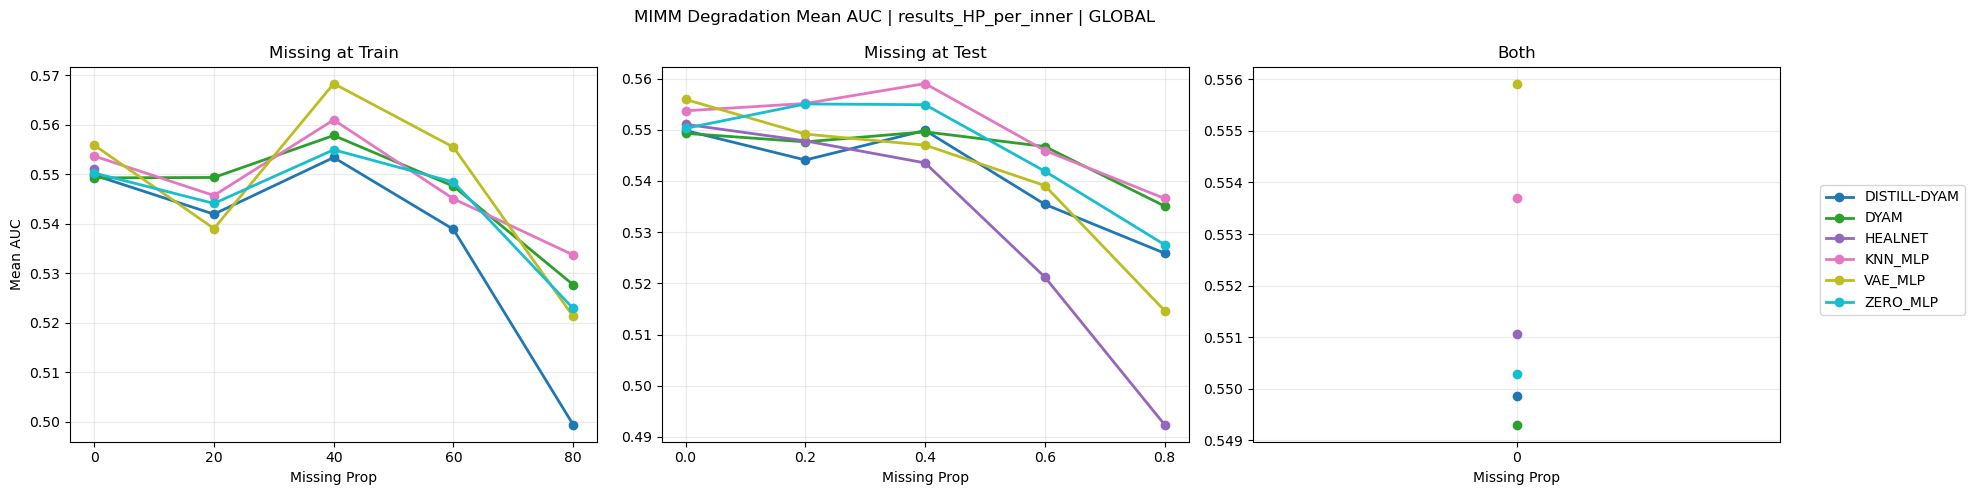

Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/figures/mimm_degradation_delta_auc_results_HP_per_inner_global.png


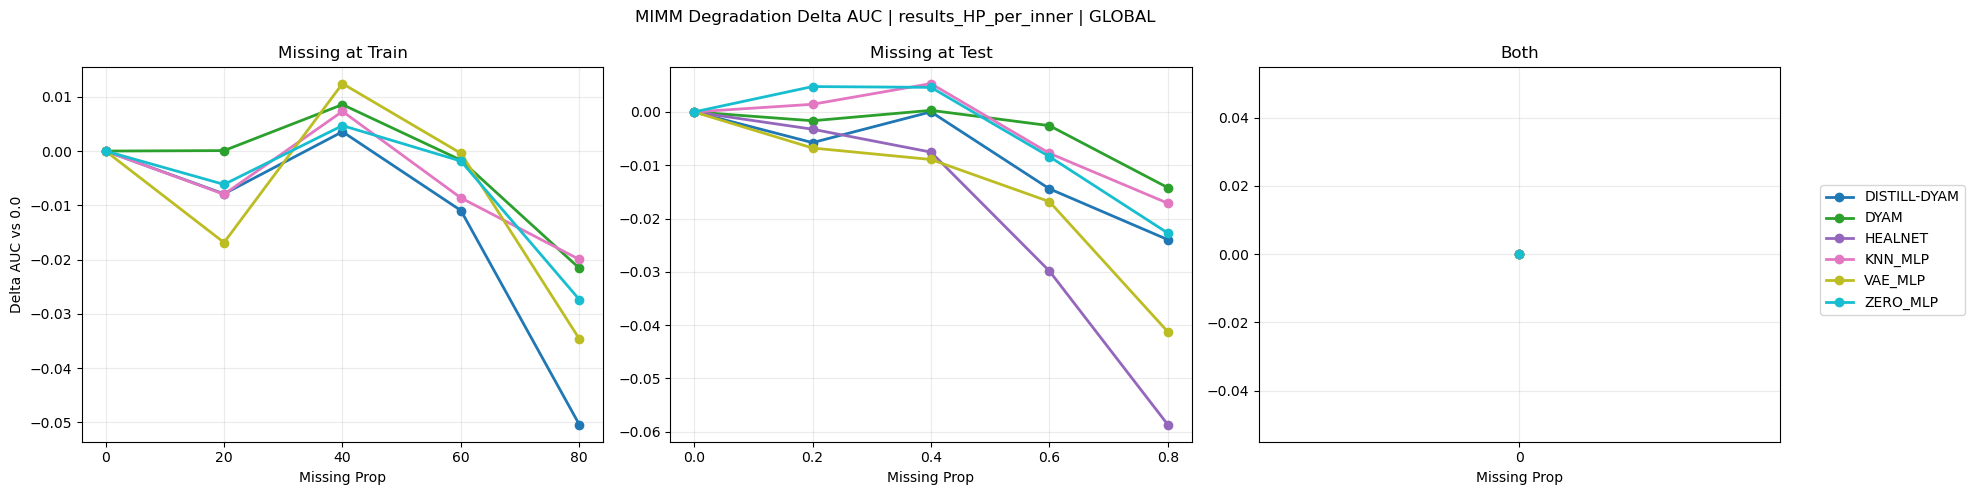

Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/figures/mimm_degradation_coefficient_results_HP_per_inner_global.png


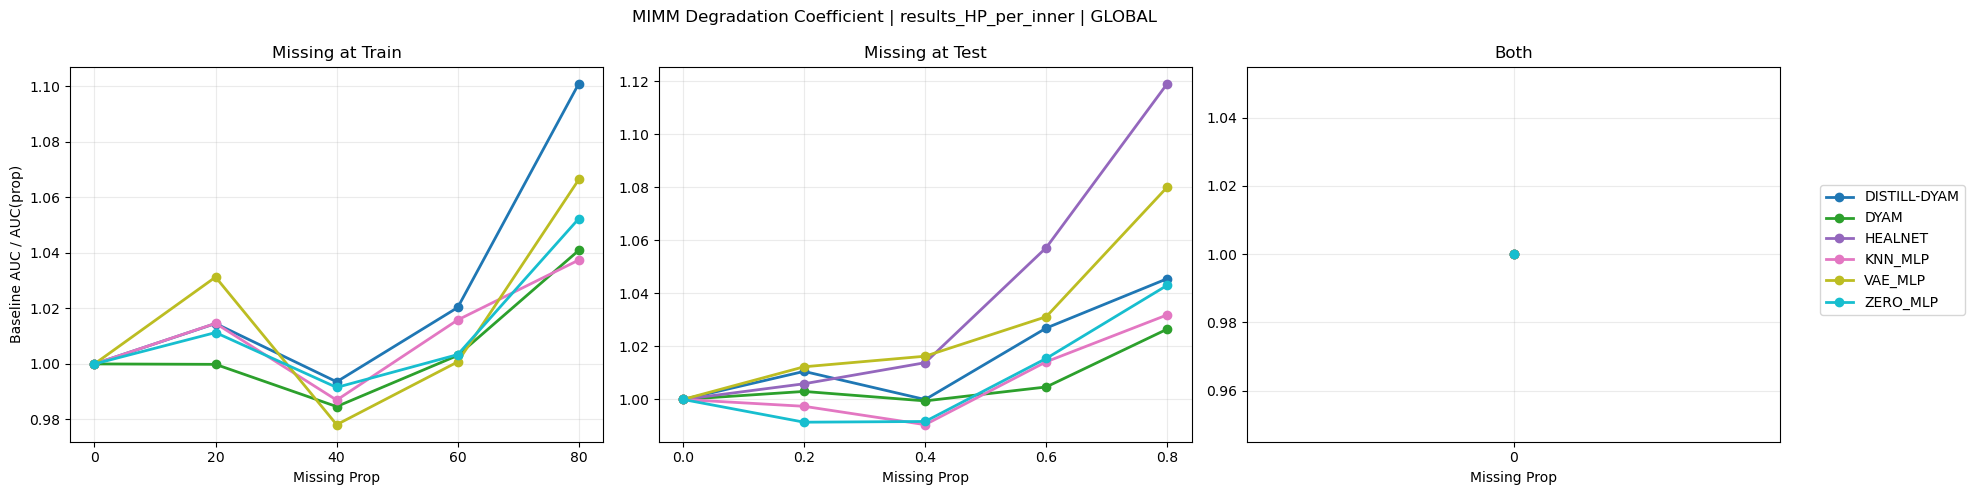

In [ ]:
figures_dir = resolve_figures_dir()
root_tag = RESULTS_ROOT.name
location_tag = TRAIN_MISSING_LOCATION.lower()

if summary_df.empty:
    print('No figures generated because summary_df is empty for the selected root.')
else:
    plot_metric_triplet(
        summary_df=summary_df,
        metric_col="mean_auc",
        title=f"MIMM Degradation Mean AUC | {root_tag} | {TRAIN_MISSING_LOCATION}",
        ylabel="Mean AUC",
        figures_dir=figures_dir,
        file_name=f"mimm_degradation_mean_auc_{root_tag}_{location_tag}.png",
    )

    plot_metric_triplet(
        summary_df=summary_df,
        metric_col="delta_auc",
        title=f"MIMM Degradation Delta AUC | {root_tag} | {TRAIN_MISSING_LOCATION}",
        ylabel="Delta AUC vs 0.0",
        figures_dir=figures_dir,
        file_name=f"mimm_degradation_delta_auc_{root_tag}_{location_tag}.png",
    )

    plot_metric_triplet(
        summary_df=summary_df,
        metric_col="degradation_coefficient",
        title=f"MIMM Degradation Coefficient | {root_tag} | {TRAIN_MISSING_LOCATION}",
        ylabel="Baseline AUC / AUC(prop)",
        figures_dir=figures_dir,
        file_name=f"mimm_degradation_coefficient_{root_tag}_{location_tag}.png",
    )

